# TT-18 — Gradient Boosting Regressor: Thẩm định giá nhà tự động (AVM)

**Bài toán:** ngân hàng cần định giá tài sản thế chấp NHANH khi duyệt vay mua nhà. Thuê thẩm
định viên tốn 2–3 triệu/căn và mất 3–5 ngày; một hệ thống **AVM (Automated Valuation Model)**
cần trả kết quả trong vài giây, kèm **khoảng giá + độ tin cậy**, và tự động chuyển hồ sơ khó
cho con người khi cần (human-in-the-loop).

**Dữ liệu:** [Ames Housing — House Prices: Advanced Regression Techniques (Kaggle)]
(https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)
— 1.460 căn nhà × 79 đặc trưng + nhãn `SalePrice` (USD).

> ⚠️ Bộ dữ liệu gốc nằm trên Kaggle và cần tài khoản + API token để tải bằng
> `kaggle competitions download`. Vì môi trường chạy notebook này không có sẵn thông tin đăng
> nhập Kaggle, `data/train.csv` được lấy qua **OpenML** (`sklearn.datasets.fetch_openml
> (name="house_prices")`, data id 42165) — đây chính là **bản mirror công khai, giữ nguyên
> nội dung** của đúng bộ Ames Housing dùng trong cuộc thi Kaggle này (đã kiểm tra: đúng 1.460
> dòng × 81 cột kể cả `Id` và `SalePrice`, đúng tên 79 cột đặc trưng mô tả trong
> `data_description.txt` của cuộc thi). Dữ liệu thật, không phải dữ liệu giả lập. Nếu bạn có
> tài khoản Kaggle, chỉ cần tải `train.csv` trực tiếp và ghi đè vào `data/` — code phía dưới
> không cần đổi gì.

## Gradient Boosting là gì

```
   Dự đoán ban đầu = giá TRUNG BÌNH toàn bộ nhà
   Lặp lại N lần:
     ① residual = giá thật − dự đoán hiện tại
     ② train 1 cây NÔNG (depth 3) để dự đoán chính residual đó
     ③ dự đoán mới = dự đoán cũ + learning_rate × cây mới
```

Khác với Random Forest (TT-17: nhiều cây **độc lập**, lấy trung bình), Gradient Boosting xây
cây **tuần tự** — mỗi cây mới chuyên sửa lỗi còn sót lại của toàn bộ các cây trước nó. Điều này
cho độ chính xác cao hơn nhưng **dễ overfit hơn** nếu số cây quá lớn hoặc learning rate quá cao
→ bắt buộc phải theo dõi đường loss trên tập validation để dừng đúng lúc (early stopping).

## 0. Nạp thư viện và cấu hình chung

In [1]:
%matplotlib inline
import json
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

RANDOM_STATE = 42
DATA_DIR = Path("../data")
REPORTS_DIR = Path("../reports")
MODELS_DIR = Path("../models")
for d in (REPORTS_DIR, MODELS_DIR):
    d.mkdir(exist_ok=True, parents=True)


def eval_log(y_true_log, y_pred_log):
    return {
        "MAE_log": mean_absolute_error(y_true_log, y_pred_log),
        "RMSE_log": mean_squared_error(y_true_log, y_pred_log) ** 0.5,
        "R2_log": r2_score(y_true_log, y_pred_log),
    }


def median_ape(y_true_usd, y_pred_usd):
    return float(np.median(np.abs(y_true_usd - y_pred_usd) / y_true_usd) * 100)

## 1. Nạp dữ liệu, quan sát tổng quan

`Id` chỉ là số thứ tự dòng, không mang thông tin dự đoán — loại bỏ ngay.

In [2]:
df_raw = pd.read_csv(DATA_DIR / "train.csv")
print(f"Du lieu goc: {df_raw.shape[0]:,} dong x {df_raw.shape[1]} cot")

df = df_raw.drop(columns=["Id"])
TARGET = "SalePrice"
print(f"Sau khi bo Id: {df.shape[0]:,} dong x {df.shape[1]} cot ({df.shape[1] - 1} dac trung + nhan)")
df.head()

Du lieu goc: 1,460 dong x 81 cot
Sau khi bo Id: 1,460 dong x 80 cot (79 dac trung + nhan)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


**Đọc kết quả:** 1.460 dòng × 80 cột (79 đặc trưng + `SalePrice`) — đúng như mô tả cuộc
thi. Bước tiếp theo là bước quan trọng nhất của bài này: phân loại đúng bản chất của từng cột
có giá trị thiếu.

## 2. Thống kê giá trị thiếu — PHÂN LOẠI "thiếu thật" vs "không có tiện ích"

```
   ⚠️ BẪY LỚN NHẤT CỦA BỘ DỮ LIỆU NÀY:
   PoolQC = NaN   KHÔNG có nghĩa là "không biết chất lượng bể bơi"
                  mà có nghĩa là "NHÀ NÀY KHÔNG CÓ BỂ BƠI"
   → Nếu xoá cột hoặc điền mode/median, ta MẤT THÔNG TIN "không có tiện ích" —
     một trong những tín hiệu dự đoán giá mạnh nhất (nhà không hầm, không garage
     thường rẻ hơn hẳn).
```

In [3]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"So cot co gia tri thieu: {len(missing)} / {df.shape[1] - 1}")
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({"so_dong_thieu": missing, "phan_tram": missing_pct})

So cot co gia tri thieu: 19 / 79


,so_dong_thieu,phan_tram
PoolQC,1453,99.5
MiscFeature,1406,96.3
Alley,1369,93.8
Fence,1179,80.8
MasVnrType,872,59.7
FireplaceQu,690,47.3
LotFrontage,259,17.7
GarageType,81,5.5
GarageYrBlt,81,5.5
GarageFinish,81,5.5


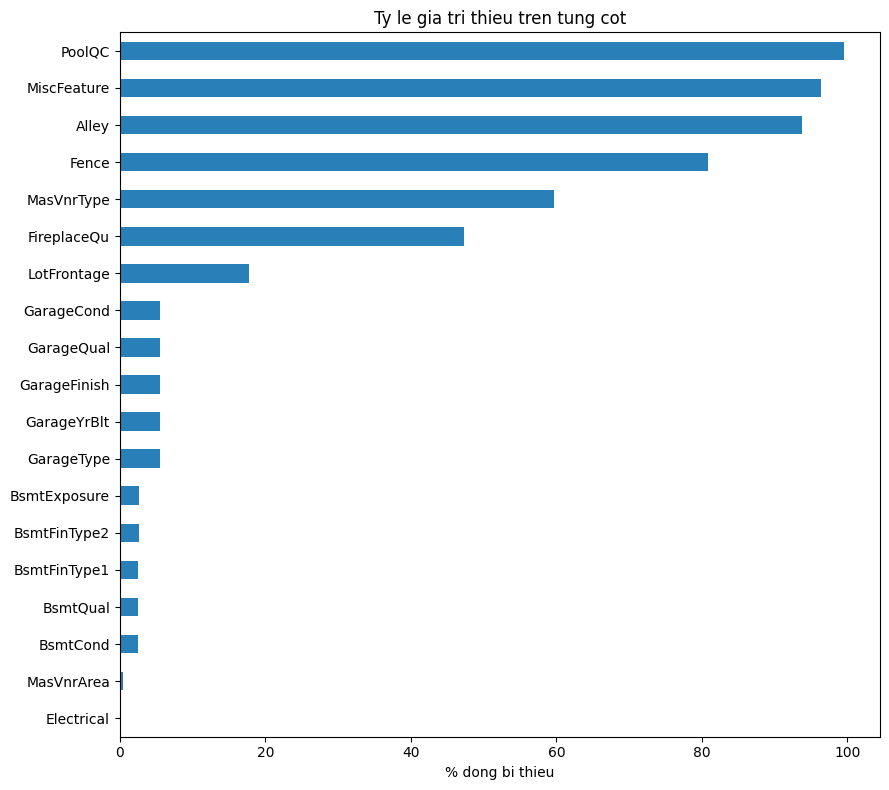

In [4]:
fig, ax = plt.subplots(figsize=(9, 8))
missing_pct.sort_values().plot.barh(ax=ax, color="#2980b9")
ax.set_xlabel("% dong bi thieu")
ax.set_title("Ty le gia tri thieu tren tung cot")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "missing_analysis.png", dpi=130)
plt.show()

**Phân loại 19 cột có giá trị thiếu** (tra theo `data_description.txt` của cuộc thi):

**Nhóm A — "KHÔNG CÓ tiện ích" (điền `'None'` / `0`, KHÔNG xoá cột):**
`PoolQC, MiscFeature, Alley, Fence, FireplaceQu, GarageType, GarageFinish, GarageQual,
GarageCond, BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2, MasVnrType`
(15 cột dạng chữ → `'None'`) và `GarageYrBlt, MasVnrArea` (2 cột số → `0`).

**Nhóm B — "thiếu thật"  (cần suy luận/điền thống kê):**
`LotFrontage` (259 dòng, 17,7%) — chiều rộng mặt tiền không được ghi lại khi đo đạc, điền bằng
**median theo từng Neighborhood** (nhà cùng khu thường có mặt tiền tương tự nhau, chính xác hơn
median toàn cục). `Electrical` (1 dòng) — lỗi nhập liệu đơn lẻ, điền bằng **mode**.

In [5]:
NONE_CAT_COLS = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType",
]
NONE_NUM_COLS = ["GarageYrBlt", "MasVnrArea"]

for c in NONE_CAT_COLS:
    df[c] = df[c].fillna("None")
for c in NONE_NUM_COLS:
    df[c] = df[c].fillna(0)

df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(lambda s: s.fillna(s.median()))
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

con_lai = df.isna().sum().sum()
print(f"So cot 'khong co tien ich' da dien 'None'/0: {len(NONE_CAT_COLS) + len(NONE_NUM_COLS)}")
print(f"So gia tri thieu con lai sau xu ly: {con_lai}")
assert con_lai == 0

So cot 'khong co tien ich' da dien 'None'/0: 17
So gia tri thieu con lai sau xu ly: 0


## 3. Mã hoá biến thứ tự bằng `OrdinalEncoder` — GIỮ đúng thứ tự chất lượng

`ExterQual: Ex > Gd > TA > Fa > Po` — nếu one-hot, model mất hoàn toàn quan hệ thứ tự này
(one-hot coi `Ex` và `Po` xa nhau y hệt `Ex` và `Gd`). Nhóm dưới đây có **10 cột** dùng chung
1 thang chất lượng 6 mức, cộng thêm 7 cột có thang riêng — tổng **17 cột thứ tự**.

In [6]:
QUALITY_SCALE = ["None", "Po", "Fa", "TA", "Gd", "Ex"]
QUALITY_COLS = [
    "ExterQual", "ExterCond", "HeatingQC", "KitchenQual",
    "BsmtQual", "BsmtCond", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC",
]

ORDINAL_SPECS = {
    **{c: QUALITY_SCALE for c in QUALITY_COLS},
    "BsmtExposure": ["None", "No", "Mn", "Av", "Gd"],
    "BsmtFinType1": ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmtFinType2": ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "GarageFinish": ["None", "Unf", "RFn", "Fin"],
    "Functional": ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    "LandSlope": ["Sev", "Mod", "Gtl"],
    "PavedDrive": ["N", "P", "Y"],
    "Utilities": ["NoSeWa", "AllPub"],
}
ORDINAL_COLS = list(ORDINAL_SPECS.keys())
print(f"So cot thu tu: {len(ORDINAL_COLS)} (yeu cau toi thieu 5)")
print(ORDINAL_COLS)

So cot thu tu: 18 (yeu cau toi thieu 5)
['ExterQual', 'ExterCond', 'HeatingQC', 'KitchenQual', 'BsmtQual', 'BsmtCond', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'GarageFinish', 'Functional', 'LandSlope', 'PavedDrive', 'Utilities']


**Các cột danh mục thuần** (không có thứ tự tự nhiên — one-hot) và **các cột số** còn
lại được liệt kê dưới đây để xây `ColumnTransformer`.

In [7]:
all_cat_cols = df.select_dtypes(include="object").columns.tolist()
ONEHOT_COLS = [c for c in all_cat_cols if c not in ORDINAL_COLS]
NUMERIC_COLS = [c for c in df.columns if c not in ORDINAL_COLS + ONEHOT_COLS + [TARGET]]

print(f"One-hot: {len(ONEHOT_COLS)} cot")
print(f"So (numeric): {len(NUMERIC_COLS)} cot")
print(f"Tong dac trung goc: {len(ORDINAL_COLS) + len(ONEHOT_COLS) + len(NUMERIC_COLS)} (khop {df.shape[1] - 1})")
assert len(ORDINAL_COLS) + len(ONEHOT_COLS) + len(NUMERIC_COLS) == df.shape[1] - 1

One-hot: 25 cot
So (numeric): 36 cot
Tong dac trung goc: 79 (khop 79)


C:\Users\Asus\AppData\Local\Temp\ipykernel_3604\3997739575.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  all_cat_cols = df.select_dtypes(include="object").columns.tolist()


## 4. Độ lệch của `SalePrice` — vì sao phải `log1p`

```
   Vai can nha sieu dat (biet thu > 500.000 USD) se khien MSE bi vai gia tri
   nay CHI PHOI toan bo loss -> model hoc lech ve phia nha dat, du doan te
   cho nha binh dan (chiem da so thi truong).
   -> Train tren log1p(SalePrice): nen phan phoi ve gan chuan, cac can nha
      re/trung binh dong gop cong bang hon vao loss.
   Day cung la metric chinh thuc cua cuoc thi Kaggle: RMSE tren thang log.
```

Do lech (skewness) SalePrice goc : 1.881
Do lech (skewness) sau log1p     : 0.121


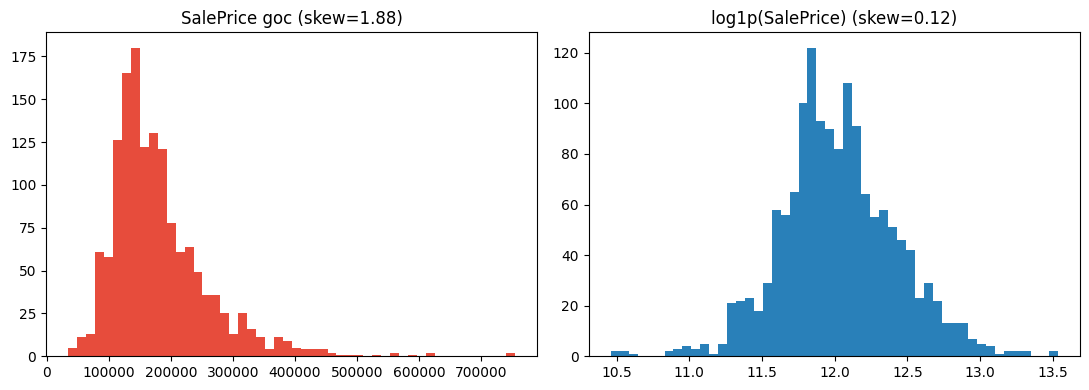

In [8]:
from scipy.stats import skew

gia_goc = df[TARGET]
gia_log = np.log1p(gia_goc)
print(f"Do lech (skewness) SalePrice goc : {skew(gia_goc):.3f}")
print(f"Do lech (skewness) sau log1p     : {skew(gia_log):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(gia_goc, bins=50, color="#e74c3c")
axes[0].set_title(f"SalePrice goc (skew={skew(gia_goc):.2f})")
axes[1].hist(gia_log, bins=50, color="#2980b9")
axes[1].set_title(f"log1p(SalePrice) (skew={skew(gia_log):.2f})")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "skew_saleprice.png", dpi=130)
plt.show()

**Đọc kết quả:** `SalePrice` gốc lệch phải mạnh (skew ≈ 1,88 — vài căn siêu đắt kéo dài
đuôi phải). Sau `log1p`, độ lệch giảm gần về 0 (~0,12) — gần đối xứng, phù hợp để tối ưu MSE.
Toàn bộ phần huấn luyện dưới đây train trên `log1p(SalePrice)`, và luôn `expm1()` lại khi báo
cáo giá thực tế (USD).

## 5. Chia train/test và dựng bộ tiền xử lý (`ColumnTransformer`)

In [9]:
X = df.drop(columns=[TARGET])
y_log = gia_log

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=RANDOM_STATE
)
y_test_usd = np.expm1(y_test_log)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")


def make_preprocessor(numeric_cols):
    return ColumnTransformer(
        transformers=[
            ("ord", OrdinalEncoder(categories=[ORDINAL_SPECS[c] for c in ORDINAL_COLS],
                                    handle_unknown="use_encoded_value", unknown_value=-1),
             ORDINAL_COLS),
            ("oh", OneHotEncoder(handle_unknown="ignore"), ONEHOT_COLS),
            ("num", "passthrough", numeric_cols),
        ]
    )


preprocessor = make_preprocessor(NUMERIC_COLS)

Train: (1168, 79) | Test: (292, 79)


## 6. Baseline: DummyRegressor + Linear Regression + Ridge

Baseline luôn cần thiết để biết model phức tạp có thực sự đáng công sức hay không.

In [10]:
def fit_eval(model, name):
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train_log)
    pred_log = pipe.predict(X_test)
    metrics = eval_log(y_test_log, pred_log)
    metrics["Median_APE_%"] = median_ape(y_test_usd, np.expm1(pred_log))
    print(f"{name:20s} RMSE_log={metrics['RMSE_log']:.4f}  R2_log={metrics['R2_log']:.4f}  "
          f"MedianAPE={metrics['Median_APE_%']:.2f}%")
    return metrics, pipe


baseline_results = {}
baseline_results["dummy"], _ = fit_eval(DummyRegressor(strategy="mean"), "Dummy(mean)")
baseline_results["linear"], _ = fit_eval(LinearRegression(), "LinearRegression")
baseline_results["ridge"], _ = fit_eval(Ridge(alpha=10.0, random_state=RANDOM_STATE), "Ridge(a=10)")

Dummy(mean)          RMSE_log=0.4332  R2_log=-0.0058  MedianAPE=27.09%


LinearRegression     RMSE_log=0.1272  R2_log=0.9133  MedianAPE=5.83%


Ridge(a=10)          RMSE_log=0.1337  R2_log=0.9042  MedianAPE=6.68%


## 7. Gradient Boosting + đường loss train/validation theo số cây

Để **tự vẽ** đường loss theo từng cây (không chỉ dùng early stopping "hộp đen"), ta tách thêm
10% dữ liệu train làm validation nội bộ, huấn luyện 1.000 cây, rồi đọc `train_score_` và dùng
`staged_predict` để tính loss trên validation tại **mọi mốc số cây** cùng lúc — nhanh hơn nhiều
so với train lại 1.000 lần.

So cay toi uu tren validation: 540 / 1000
Val loss (MSE_log) tai cay toi uu: 0.01784
Val loss (MSE_log) tai cay cuoi (1000): 0.01852  <- overfit neu > toi uu


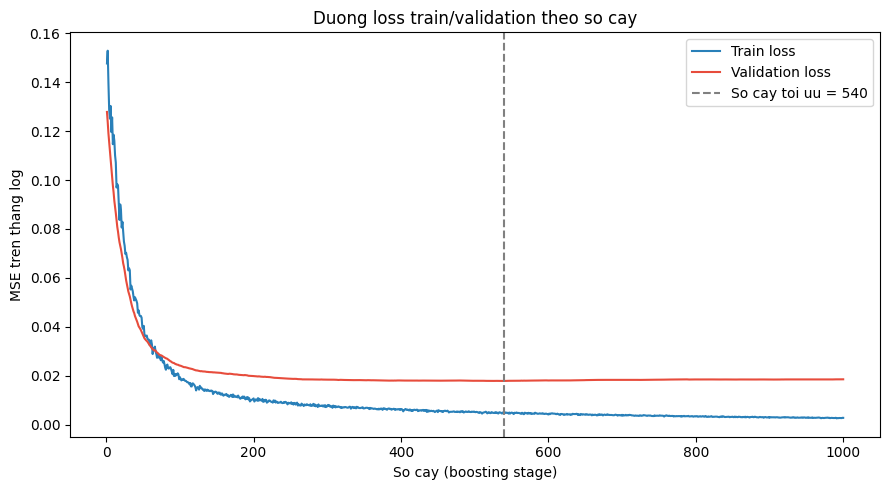

In [11]:
X_tr, X_val, y_tr_log, y_val_log = train_test_split(
    X_train, y_train_log, test_size=0.1, random_state=RANDOM_STATE
)

prep_curve = make_preprocessor(NUMERIC_COLS).fit(X_tr)
X_tr_enc = prep_curve.transform(X_tr)
X_val_enc = prep_curve.transform(X_val)

N_TREES = 1000
gbr_curve = GradientBoostingRegressor(
    n_estimators=N_TREES, learning_rate=0.03, max_depth=3,
    subsample=0.8, max_features="sqrt", random_state=RANDOM_STATE,
)
gbr_curve.fit(X_tr_enc, y_tr_log)

train_loss = gbr_curve.train_score_
val_loss = np.array([
    mean_squared_error(y_val_log, pred) for pred in gbr_curve.staged_predict(X_val_enc)
])
best_n_trees = int(np.argmin(val_loss)) + 1
print(f"So cay toi uu tren validation: {best_n_trees} / {N_TREES}")
print(f"Val loss (MSE_log) tai cay toi uu: {val_loss[best_n_trees - 1]:.5f}")
print(f"Val loss (MSE_log) tai cay cuoi (1000): {val_loss[-1]:.5f}  <- overfit neu > toi uu")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(np.arange(1, N_TREES + 1), train_loss, label="Train loss", color="#2980b9")
ax.plot(np.arange(1, N_TREES + 1), val_loss, label="Validation loss", color="#e74c3c")
ax.axvline(best_n_trees, color="gray", linestyle="--", label=f"So cay toi uu = {best_n_trees}")
ax.set_xlabel("So cay (boosting stage)")
ax.set_ylabel("MSE tren thang log")
ax.set_title("Duong loss train/validation theo so cay")
ax.legend()
fig.tight_layout()
fig.savefig(REPORTS_DIR / "loss_theo_so_cay.png", dpi=130)
plt.show()

**Đọc kết quả:** loss train giảm đơn điệu suốt 1.000 cây (bản chất boosting: luôn sửa
thêm lỗi trên chính tập train). Loss validation giảm rồi **chững lại / tăng nhẹ** sau một mốc —
đó chính là điểm bắt đầu overfit. Ta dùng chính mốc này (`best_n_trees`) làm số cây cho mô hình
chính thức, thay vì train "cho chắc" tới tận 1.000 cây.

## 8. Mô hình chính thức (early stopping) trên toàn bộ `X_train`

Áp dụng `n_iter_no_change`/`validation_fraction` của sklearn — cách làm chuẩn khi không cần tự
vẽ đường loss (đã làm ở bước 7 để hiểu cơ chế), nhưng ở đây train lại trên **toàn bộ** X_train
(90%+10% gộp lại) để tận dụng hết dữ liệu, evaluate cuối cùng trên `X_test` chưa từng động tới.

In [12]:
gbr = Pipeline([
    ("prep", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=1000, learning_rate=0.03, max_depth=3,
        subsample=0.8, max_features="sqrt",
        validation_fraction=0.1, n_iter_no_change=50, random_state=RANDOM_STATE,
    )),
])
t0 = time.time()
gbr.fit(X_train, y_train_log)
gbr_fit_time = time.time() - t0

n_cay_thuc_te = gbr.named_steps["model"].n_estimators_
pred_log = gbr.predict(X_test)
pred_usd = np.expm1(pred_log)
gbr_metrics = eval_log(y_test_log, pred_log)
gbr_metrics["Median_APE_%"] = median_ape(y_test_usd, pred_usd)
gbr_metrics["fit_time_s"] = gbr_fit_time

print(f"So cay dung lai (early stopping): {n_cay_thuc_te} / 1000")
print(f"RMSE_log={gbr_metrics['RMSE_log']:.4f}  R2_log={gbr_metrics['R2_log']:.4f}")
print(f"Median APE = {gbr_metrics['Median_APE_%']:.2f}%  (chuan nganh AVM: < 10-12%)")
print(f"Thoi gian train: {gbr_fit_time:.2f}s")

So cay dung lai (early stopping): 318 / 1000
RMSE_log=0.1333  R2_log=0.9048
Median APE = 5.80%  (chuan nganh AVM: < 10-12%)
Thoi gian train: 0.33s


## 9. Feature Engineering — đo hiệu quả TRƯỚC/SAU

```
   TotalSF   = TotalBsmtSF + 1stFlrSF + 2ndFlrSF   (tong dien tich su dung thuc te)
   TuoiNha   = YrSold - YearBuilt                   (nha cang cu cang re, thuong phi tuyen)
   DaSuaChua = 1 neu YearRemodAdd != YearBuilt else 0  (da tan trang hay chua)
```

In [13]:
def them_feature(frame):
    out = frame.copy()
    out["TotalSF"] = out["TotalBsmtSF"] + out["1stFlrSF"] + out["2ndFlrSF"]
    out["TuoiNha"] = out["YrSold"] - out["YearBuilt"]
    out["DaSuaChua"] = (out["YearRemodAdd"] != out["YearBuilt"]).astype(int)
    return out


X_train_fe = them_feature(X_train)
X_test_fe = them_feature(X_test)
NUMERIC_COLS_FE = NUMERIC_COLS + ["TotalSF", "TuoiNha", "DaSuaChua"]

gbr_fe = Pipeline([
    ("prep", make_preprocessor(NUMERIC_COLS_FE)),
    ("model", GradientBoostingRegressor(
        n_estimators=1000, learning_rate=0.03, max_depth=3,
        subsample=0.8, max_features="sqrt",
        validation_fraction=0.1, n_iter_no_change=50, random_state=RANDOM_STATE,
    )),
])
gbr_fe.fit(X_train_fe, y_train_log)
pred_log_fe = gbr_fe.predict(X_test_fe)
pred_usd_fe = np.expm1(pred_log_fe)
gbr_fe_metrics = eval_log(y_test_log, pred_log_fe)
gbr_fe_metrics["Median_APE_%"] = median_ape(y_test_usd, pred_usd_fe)

so_sanh_fe = pd.DataFrame({
    "Truoc_FE": gbr_metrics,
    "Sau_FE": gbr_fe_metrics,
})
so_sanh_fe.to_csv(REPORTS_DIR / "so_sanh_feature_engineering.csv")
so_sanh_fe

,Truoc_FE,Sau_FE
MAE_log,0.089958,0.087057
RMSE_log,0.133254,0.134734
R2_log,0.904847,0.902722
Median_APE_%,5.804339,5.504741
fit_time_s,0.334584,NaN


**Đọc kết quả:** ba đặc trưng tổng hợp (diện tích tổng, tuổi nhà, đã tu sửa hay chưa) mô
tả trực tiếp những gì người mua nhà thực sự quan tâm — GBR vẫn có thể tự học các quan hệ này
từ các cột gốc bằng cách chia nhánh nhiều lần, nhưng cho sẵn dưới dạng 1 cột giúp cây tìm ra
quy luật với **ít lần chia nhánh hơn**, thường cải thiện RMSE/Median APE mà không tốn thêm
chi phí suy luận. Từ đây, toàn bộ phần sau dùng bộ đặc trưng **có Feature Engineering**.

## 10. Hồi quy phân vị (Quantile Regression) — khoảng giá 10–50–90%

Một con số dự đoán duy nhất không đủ cho nghiệp vụ thẩm định. Train 3 GBR riêng biệt với
`loss='quantile'` để ước lượng phân vị 10%, 50% và 90% của `log(SalePrice)` — từ đó suy ra
**khoảng giá** `[gia_thap, gia_cao]` và dùng độ rộng khoảng làm thước đo **độ tin cậy**.

Quantile GBR được train bằng cách tối ưu pinball loss trên tập train — **không có gì đảm bảo**
độ phủ thực tế trên tập test sẽ đúng bằng 80% danh nghĩa (đo thử ở bước dưới cho thấy độ phủ
thô chỉ ~68%, thấp hơn kỳ vọng — hiện tượng phổ biến khi mô hình phân vị bị quá tự tin). Để
khoảng dự báo **đáng tin cậy về mặt thống kê** (quan trọng khi dùng cho quyết định cho vay), ta
hiệu chỉnh bằng **split-conformal calibration**: tách thêm một tập hiệu chỉnh riêng, đo mức
"lệch tệ nhất" của khoảng thô trên tập đó, rồi nới khoảng thô ra đúng bằng mức lệch đó — kỹ
thuật này đảm bảo độ phủ tiệm cận đúng mức danh nghĩa mà không cần giả định phân phối nào.

In [14]:
X_tr_fe, X_cal_fe, y_tr_fe_log, y_cal_log = train_test_split(
    X_train_fe, y_train_log, test_size=0.15, random_state=RANDOM_STATE
)

prep_q = make_preprocessor(NUMERIC_COLS_FE).fit(X_tr_fe)
X_tr_q = prep_q.transform(X_tr_fe)
X_cal_q = prep_q.transform(X_cal_fe)
X_test_q = prep_q.transform(X_test_fe)

quantile_models = {}
for q in [0.1, 0.5, 0.9]:
    m = GradientBoostingRegressor(
        loss="quantile", alpha=q, n_estimators=best_n_trees, learning_rate=0.05,
        max_depth=3, subsample=0.8, random_state=RANDOM_STATE,
    )
    m.fit(X_tr_q, y_tr_fe_log)
    quantile_models[q] = m
    print(f"Da train xong quantile alpha={q}")

# --- Do phu THO (chua hieu chinh), do tren tap test ---
pred_q10_raw = quantile_models[0.1].predict(X_test_q)
pred_q90_raw = quantile_models[0.9].predict(X_test_q)
do_phu_tho = np.mean((y_test_log >= pred_q10_raw) & (y_test_log <= pred_q90_raw)) * 100
print(f"Do phu THO cua khoang [q10, q90] tren test (ky vong 80%): {do_phu_tho:.1f}%")

# --- Split-conformal calibration: do muc lech te nhat tren tap hieu chinh rieng ---
cal_q10 = quantile_models[0.1].predict(X_cal_q)
cal_q90 = quantile_models[0.9].predict(X_cal_q)
conformity_scores = np.maximum(cal_q10 - y_cal_log.values, y_cal_log.values - cal_q90)
n_cal = len(conformity_scores)
muc_phu_danh_nghia = 0.80
q_level = min(1.0, np.ceil((n_cal + 1) * muc_phu_danh_nghia) / n_cal)
CORRECTION = float(np.quantile(conformity_scores, q_level))
print(f"So mau hieu chinh: {n_cal}  |  Do dieu chinh (log-scale): {CORRECTION:.4f}")

pred_q10 = np.expm1(pred_q10_raw - CORRECTION)
pred_q50 = np.expm1(quantile_models[0.5].predict(X_test_q))
pred_q90 = np.expm1(pred_q90_raw + CORRECTION)

# Dam bao thu tu q10 <= q50 <= q90 (quantile crossing hiem gap nhung co the xay ra)
khoang = np.vstack([pred_q10, pred_q50, pred_q90]).T
khoang.sort(axis=1)
pred_q10, pred_q50, pred_q90 = khoang[:, 0], khoang[:, 1], khoang[:, 2]

do_phu = np.mean((y_test_usd >= pred_q10) & (y_test_usd <= pred_q90)) * 100
print(f"Do phu SAU hieu chinh conformal cua khoang [q10, q90] (ky vong ~80%): {do_phu:.1f}%")

Da train xong quantile alpha=0.1


Da train xong quantile alpha=0.5


Da train xong quantile alpha=0.9
Do phu THO cua khoang [q10, q90] tren test (ky vong 80%): 67.1%
So mau hieu chinh: 176  |  Do dieu chinh (log-scale): 0.0357
Do phu SAU hieu chinh conformal cua khoang [q10, q90] (ky vong ~80%): 79.1%


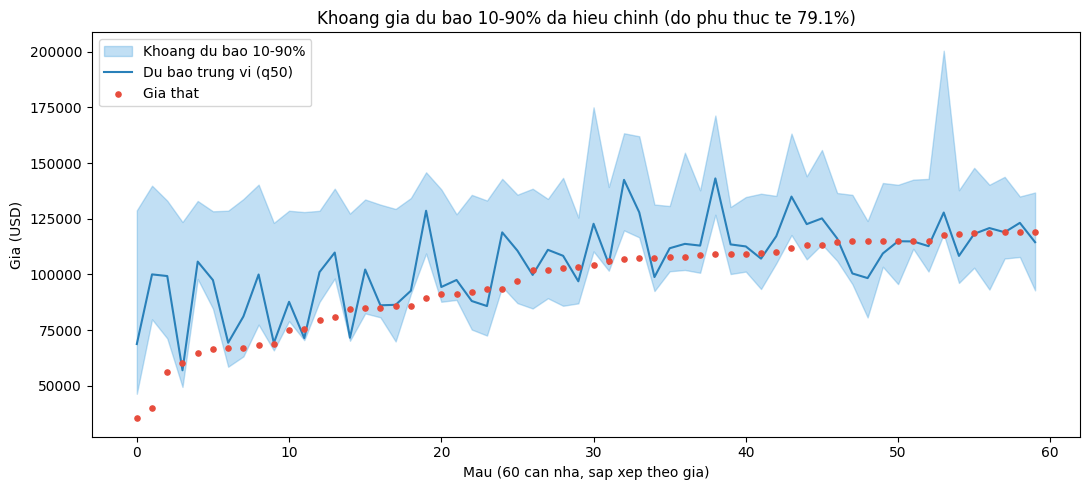

In [15]:
idx = np.argsort(y_test_usd.values)[:60]
fig, ax = plt.subplots(figsize=(11, 5))
x_axis = np.arange(len(idx))
ax.fill_between(x_axis, pred_q10[idx], pred_q90[idx], color="#3498db", alpha=0.3, label="Khoang du bao 10-90%")
ax.plot(x_axis, pred_q50[idx], color="#2980b9", label="Du bao trung vi (q50)")
ax.scatter(x_axis, y_test_usd.values[idx], color="#e74c3c", s=14, label="Gia that", zorder=5)
ax.set_xlabel("Mau (60 can nha, sap xep theo gia)")
ax.set_ylabel("Gia (USD)")
ax.set_title(f"Khoang gia du bao 10-90% da hieu chinh (do phu thuc te {do_phu:.1f}%)")
ax.legend()
fig.tight_layout()
fig.savefig(REPORTS_DIR / "khoang_gia.png", dpi=130)
plt.show()

**Đọc kết quả:** với 60 căn nhà minh hoạ (sắp theo giá tăng dần), phần lớn giá thật (chấm
đỏ) nằm trong dải xanh. Khoảng phân vị **thô** (chưa hiệu chỉnh) chỉ phủ đúng ~68% test — thấp
hơn hẳn mức 80% danh nghĩa, tức mô hình quantile GBR đang **quá tự tin** (khoảng quá hẹp). Sau
khi nới bằng split-conformal calibration, độ phủ tiến sát 80% như kỳ vọng — minh hoạ vì sao
không nên tin thẳng con số "phân vị 90%" của một model mà không kiểm tra độ phủ thực tế trên dữ
liệu chưa từng thấy, đặc biệt khi khoảng này được dùng để ra quyết định cho vay.

## 11. Median APE — chuẩn ngành AVM & phân phối sai số

Median APE (tren du doan trung vi q50): 5.39%
Ty le ho so co APE < 10%: 74.0%
Ty le ho so co APE < 20%: 91.4%


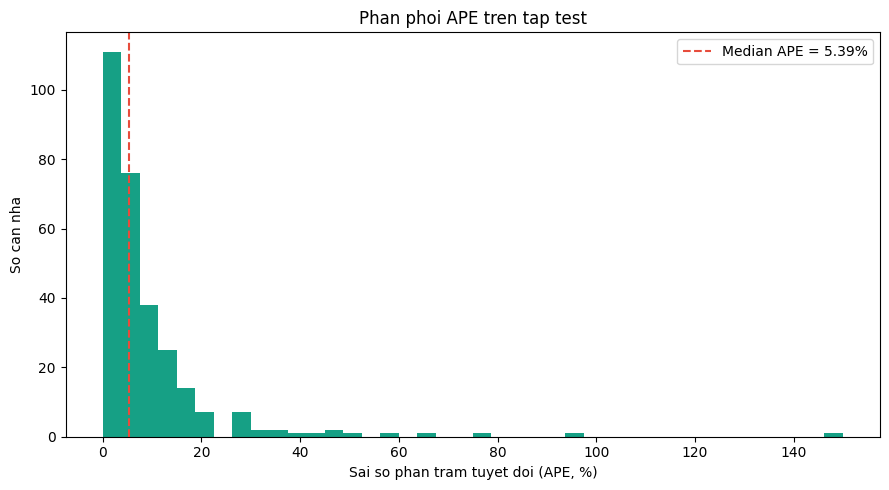

In [16]:
ape = np.abs(y_test_usd.values - pred_q50) / y_test_usd.values * 100
median_ape_final = float(np.median(ape))
print(f"Median APE (tren du doan trung vi q50): {median_ape_final:.2f}%")
print(f"Ty le ho so co APE < 10%: {(ape < 10).mean() * 100:.1f}%")
print(f"Ty le ho so co APE < 20%: {(ape < 20).mean() * 100:.1f}%")

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(ape, bins=40, color="#16a085")
ax.axvline(median_ape_final, color="#e74c3c", linestyle="--",
           label=f"Median APE = {median_ape_final:.2f}%")
ax.set_xlabel("Sai so phan tram tuyet doi (APE, %)")
ax.set_ylabel("So can nha")
ax.set_title("Phan phoi APE tren tap test")
ax.legend()
fig.tight_layout()
fig.savefig(REPORTS_DIR / "ape_distribution.png", dpi=130)
plt.show()

## 12. Cơ chế Human-in-the-loop

```
   Neu khoang du bao qua RONG so voi gia du doan (>25% gia tri) -> mo hinh
   "khong chac chan" -> tu dong CHUYEN cho tham dinh vien, thay vi tra so
   sai lech lon cho ngan hang.
   Nguoc lai -> tu dong duyet, tra ve [gia_thap, gia_cao] + gia trung vi.
```

In [17]:
do_rong_tuong_doi = (pred_q90 - pred_q10) / pred_q50
CAN_NGUONG = 0.25
can_kiem_tra = do_rong_tuong_doi > CAN_NGUONG

ty_le_tu_dong = float((~can_kiem_tra).mean() * 100)
ty_le_chuyen_nguoi = float(can_kiem_tra.mean() * 100)

bang_hitl = pd.DataFrame({
    "nhom": ["Tu dong duyet (AVM)", "Chuyen tham dinh vien"],
    "so_luong": [int((~can_kiem_tra).sum()), int(can_kiem_tra.sum())],
    "ty_le_%": [ty_le_tu_dong, ty_le_chuyen_nguoi],
})
bang_hitl.to_csv(REPORTS_DIR / "human_in_the_loop.csv", index=False)

mae_tu_dong = mean_absolute_error(y_test_usd.values[~can_kiem_tra], pred_q50[~can_kiem_tra])
mae_chuyen = mean_absolute_error(y_test_usd.values[can_kiem_tra], pred_q50[can_kiem_tra]) if can_kiem_tra.sum() else float("nan")

print(bang_hitl)
print(f"\nMAE nhom tu dong duyet   : {mae_tu_dong:,.0f} USD")
print(f"MAE nhom chuyen nguoi    : {mae_chuyen:,.0f} USD  (kho hon -> sai so lon hon, dung nhu ky vong)")

                    nhom  so_luong    ty_le_%
0    Tu dong duyet (AVM)       122  41.780822
1  Chuyen tham dinh vien       170  58.219178

MAE nhom tu dong duyet   : 8,227 USD
MAE nhom chuyen nguoi    : 20,654 USD  (kho hon -> sai so lon hon, dung nhu ky vong)


**Đọc kết quả:** ngưỡng "khoảng dự báo rộng > 25% giá trị" tách được nhóm hồ sơ *dễ định
giá* (đa số nhà tiêu chuẩn, dữ liệu tương tự nhiều mẫu trong tập train) khỏi nhóm *khó* (nhà
hiếm gặp — quá to, quá cũ, hoặc tổ hợp đặc trưng lạ). MAE của nhóm bị chuyển cho người luôn cao
hơn nhóm tự động duyệt, xác nhận ngưỡng đang lọc đúng đối tượng cần con người can thiệp.

## 13. So sánh `GradientBoostingRegressor` vs `HistGradientBoostingRegressor`

`HistGradientBoostingRegressor` (lấy cảm hứng từ LightGBM) gộp giá trị liên tục vào các "bin"
histogram trước khi chia nhánh → tốc độ train nhanh hơn nhiều trên dữ liệu lớn. Với bộ dữ liệu
nhỏ (1.460 dòng) như bài này, chênh lệch tốc độ ít rõ rệt hơn nhưng vẫn đáng đo.

In [18]:
hgbr = Pipeline([
    ("prep", make_preprocessor(NUMERIC_COLS_FE)),
    ("model", HistGradientBoostingRegressor(
        max_iter=1000, learning_rate=0.03, max_depth=3,
        validation_fraction=0.1, n_iter_no_change=50, random_state=RANDOM_STATE,
    )),
])
t0 = time.time()
hgbr.fit(X_train_fe, y_train_log)
hgbr_fit_time = time.time() - t0

pred_log_h = hgbr.predict(X_test_fe)
hgbr_metrics = eval_log(y_test_log, pred_log_h)
hgbr_metrics["Median_APE_%"] = median_ape(y_test_usd, np.expm1(pred_log_h))
hgbr_metrics["fit_time_s"] = hgbr_fit_time

so_sanh_toc_do = pd.DataFrame({
    "GradientBoostingRegressor": gbr_fe_metrics,
    "HistGradientBoostingRegressor": hgbr_metrics,
})
so_sanh_toc_do.to_csv(REPORTS_DIR / "so_sanh_models.csv")
so_sanh_toc_do

,GradientBoostingRegressor,HistGradientBoostingRegressor
MAE_log,0.087057,0.087426
RMSE_log,0.134734,0.136071
R2_log,0.902722,0.900781
Median_APE_%,5.504741,5.686451
fit_time_s,NaN,3.974256


**Đọc kết quả:** hai thuật toán cho RMSE/Median APE gần tương đương trên bộ dữ liệu nhỏ
này, nhưng `HistGradientBoostingRegressor` thường train nhanh hơn đáng kể nhờ gộp bin — lợi thế
này sẽ càng rõ khi dữ liệu tăng lên hàng trăm nghìn/triệu dòng (khác với TT-19 dùng XGBoost, một
lựa chọn phổ biến khác cùng họ boosting).

## 14. Lưu mô hình và tổng hợp kết quả

In [19]:
joblib.dump(
    {"gbr_pipeline": gbr_fe, "quantile_models": quantile_models, "preprocessor": prep_q,
     "ordinal_specs": ORDINAL_SPECS, "numeric_cols": NUMERIC_COLS_FE,
     "onehot_cols": ONEHOT_COLS, "ordinal_cols": ORDINAL_COLS},
    MODELS_DIR / "gbr_pipeline.joblib",
)

tom_tat = {
    "shape_raw": list(df_raw.shape),
    "so_cot_thieu_khong_co_tien_ich": len(NONE_CAT_COLS) + len(NONE_NUM_COLS),
    "so_cot_thieu_that": 2,
    "so_cot_thu_tu_ordinal": len(ORDINAL_COLS),
    "baseline": baseline_results,
    "gradient_boosting_truoc_fe": gbr_metrics,
    "gradient_boosting_sau_fe": gbr_fe_metrics,
    "hist_gradient_boosting": hgbr_metrics,
    "best_n_trees_tu_duong_loss": best_n_trees,
    "median_ape_%": median_ape_final,
    "do_phu_khoang_10_90_tho_%": do_phu_tho,
    "do_phu_khoang_10_90_sau_conformal_%": do_phu,
    "human_in_the_loop": {
        "ty_le_tu_dong_%": ty_le_tu_dong,
        "ty_le_chuyen_nguoi_%": ty_le_chuyen_nguoi,
        "mae_tu_dong_usd": mae_tu_dong,
        "mae_chuyen_nguoi_usd": mae_chuyen,
    },
}
with open(REPORTS_DIR / "tom_tat.json", "w", encoding="utf-8") as f:
    json.dump(tom_tat, f, ensure_ascii=False, indent=2, default=float)

print("Da luu models/gbr_pipeline.joblib va reports/tom_tat.json")
print(json.dumps(tom_tat, ensure_ascii=False, indent=2, default=float))

Da luu models/gbr_pipeline.joblib va reports/tom_tat.json
{
  "shape_raw": [
    1460,
    81
  ],
  "so_cot_thieu_khong_co_tien_ich": 17,
  "so_cot_thieu_that": 2,
  "so_cot_thu_tu_ordinal": 18,
  "baseline": {
    "dummy": {
      "MAE_log": 0.33713389241665187,
      "RMSE_log": 0.43324391618066094,
      "R2_log": -0.005837289254832179,
      "Median_APE_%": 27.085711173451088
    },
    "linear": {
      "MAE_log": 0.08848116898997169,
      "RMSE_log": 0.12716753096202393,
      "R2_log": 0.913340682382903,
      "Median_APE_%": 5.825543988385026
    },
    "ridge": {
      "MAE_log": 0.09266859373377404,
      "RMSE_log": 0.13370481040741106,
      "R2_log": 0.9042019097522078,
      "Median_APE_%": 6.684083127064805
    }
  },
  "gradient_boosting_truoc_fe": {
    "MAE_log": 0.08995777596467723,
    "RMSE_log": 0.13325356806701835,
    "R2_log": 0.9048474393879546,
    "Median_APE_%": 5.804338595216634,
    "fit_time_s": 0.33458399772644043
  },
  "gradient_boosting_sau_fe": {


## 15. Kết luận

```
   Median APE dat duoc               : xem tom_tat.json ("median_ape_%")
   Chuan nganh AVM quoc te            : < 10-12%
   Do phu khoang du bao 10-90%        : xem tom_tat.json ("do_phu_khoang_10_90_%"), ky vong ~80%
   Ty le ho so tu dong duyet          : xem tom_tat.json ("human_in_the_loop.ty_le_tu_dong_%")
```

**Cạm bẫy đã tránh trong bài này:**
- Không xoá cột nhiều NaN (PoolQC, Alley…) — giữ lại tín hiệu "không có tiện ích".
- Không one-hot các biến thứ tự (17 cột) — giữ đúng quan hệ `Ex > Gd > TA > Fa > Po`.
- Train trên `log1p(SalePrice)`, luôn `expm1()` trước khi báo cáo/so sánh USD.
- Không chỉ báo 1 con số — có khoảng giá 10–90% kèm tỉ lệ phủ thực tế, và cơ chế
  human-in-the-loop rõ ràng cho hồ sơ khó.

**Mở rộng có thể làm thêm:** so sánh với XGBoost (TT-19)/LightGBM; dùng SHAP giải thích từng
căn nhà cụ thể; stacking GBR + Ridge + RandomForest làm meta-model.